In [1]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nib
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
V1 = pd.read_csv('../Derivatives/wang_V1_structural.csv')
A1 = pd.read_csv('../Derivatives/julich_A1_structural.csv')

In [3]:
blind_thalamus = pd.read_csv('../Derivatives/blind_thomas.csv').loc[:, ['1-THALAMUS', '2-AV', '4-VA', '5-VLa', '6-VLP', '7-VPL', '8-Pul',
       '9-LGN', '10-MGN','subject', 'group']].groupby(['subject', 'group']).mean().reset_index()
deaf_thalamus = pd.read_csv('../Derivatives/deaf_thomas.csv').loc[:, ['1-THALAMUS', '2-AV', '4-VA', '5-VLa', '6-VLP', '7-VPL', '8-Pul',
       '9-LGN', '10-MGN','subject', 'group']].groupby(['subject', 'group']).mean().reset_index()

In [4]:
V1 = pd.merge(blind_thalamus, V1, on=['subject', 'group'])
A1 = pd.merge(deaf_thalamus, A1, on=['subject', 'group'])

['eb', 0.60229072450275, 0.01750130904896344]
['eb', -0.21375965442921477, 0.44428804650942855]
['eb', 0.5302736049834902, 0.04201033938425515]
['sc', 0.3346894436494518, 0.16132845330166554]
['sc', -0.006041584797573197, 0.9804163899439464]
['sc', 0.36194030857553783, 0.1278270887785002]


/tmp/ipykernel_1696984/2543575276.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group[y] = df_group[y].astype(float)
/tmp/ipykernel_1696984/2543575276.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group[x] = df_group[x].astype(float)
/tmp/ipykernel_1696984/2543575276.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

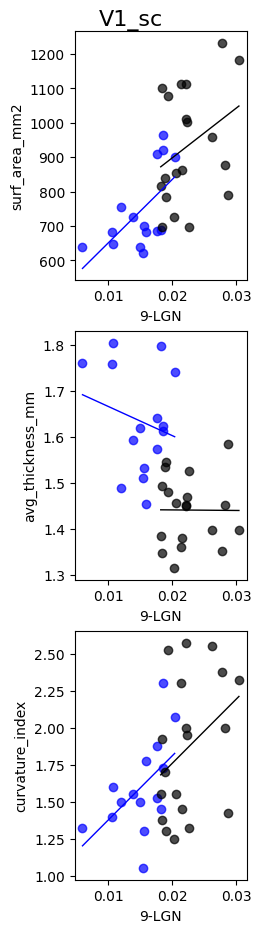

In [5]:
ys = ['surf_area_mm2', 'avg_thickness_mm', 'curvature_index']
xs = ['9-LGN'] #, 'SC', 'IC', 'SOC'] #'1-THALAMUS', 
colors = ['blue', 'black']
n_rows = len(ys)
n_cols = len(xs)

for regionlabel, region in zip(['V1'], [V1]):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5*n_cols, 3*n_rows), constrained_layout=True)
    for g, group in enumerate(['eb', 'sc']):
        df_group = region[region['group']==group]
        fig.suptitle(regionlabel + '_' + group, fontsize=16, y=1.02)

        for i, y in enumerate(ys):
                df_group[y] = df_group[y].astype(float)
                for j, x in enumerate(xs):
                        df_group[x] = df_group[x].astype(float)
                        
                        # Group by subject
                        df = df_group.loc[:, [x, y, 'subject']].groupby('subject').mean().reset_index()
                        
                        ax = axes[i] if n_rows > 1 else axes[j]
                        ax.scatter(df[x], df[y], alpha=0.7, color=colors[g])
                        
                        # Fit correlation line
                        slope, intercept, r_value, p_value, _ = stats.linregress(df[x], df[y])
                        x_vals = np.linspace(df[x].min(), df[x].max(), 100)
                        y_vals = slope * x_vals + intercept
                        ax.plot(x_vals, y_vals, color=colors[g], lw=1)
                        
                        # Annotate r and p
                        #ax.text(0.05, 0.95, f"r={r_value:.2f}\np={p_value:.3f}", 
                        #        transform=ax.transAxes, va='top', ha='left', fontsize=10)
                        print([group, r_value, p_value])
                        ax.set_xlabel(x)
                        ax.set_ylabel(y)

['Deaf', -0.23982554358251776, 0.24821911644546285]
['Deaf', -0.15714968970353527, 0.4531335669932226]
['Deaf', -0.10044262923058393, 0.6328545711083062]
['Control', -0.026337385816472304, 0.8901219837282173]
['Control', 0.0012115002289477682, 0.994930524724492]
['Control', -0.2139983757167077, 0.2561541799475375]


/tmp/ipykernel_1696984/2034494275.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group[y] = df_group[y].astype(float)
/tmp/ipykernel_1696984/2034494275.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group[x] = df_group[x].astype(float)
/tmp/ipykernel_1696984/2034494275.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

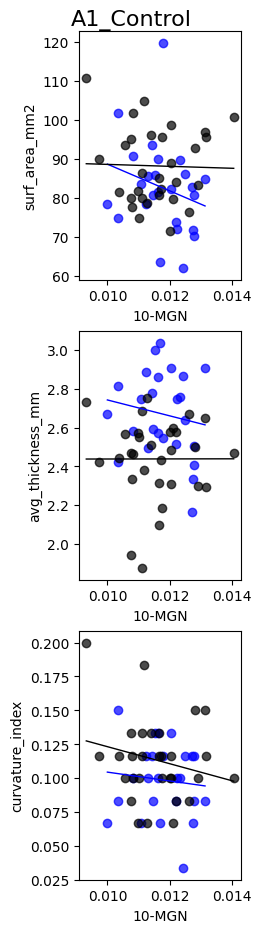

In [6]:
ys = ['surf_area_mm2', 'avg_thickness_mm', 'curvature_index']
xs = ['10-MGN'] #, 'SC', 'IC', 'SOC'] #'1-THALAMUS', 

colors = ['blue', 'black']

n_rows = len(ys)
n_cols = len(xs)

for regionlabel, region in zip(['A1'], [A1]):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5*n_cols, 3*n_rows), constrained_layout=True)
    for g, group in enumerate(['Deaf', 'Control']):
        df_group = region[region['group']==group]
        fig.suptitle(regionlabel + '_' + group, fontsize=16, y=1.02)

        for i, y in enumerate(ys):
                df_group[y] = df_group[y].astype(float)
                for j, x in enumerate(xs):
                        df_group[x] = df_group[x].astype(float)
                        
                        # Group by subject
                        df = df_group.loc[:, [x, y, 'subject']].groupby('subject').mean().reset_index()
                        
                        ax = axes[i] if n_rows > 1 else axes[j]
                        ax.scatter(df[x], df[y], alpha=0.7, color=colors[g])
                        
                        # Fit correlation line
                        slope, intercept, r_value, p_value, _ = stats.linregress(df[x], df[y])
                        x_vals = np.linspace(df[x].min(), df[x].max(), 100)
                        y_vals = slope * x_vals + intercept
                        ax.plot(x_vals, y_vals, color=colors[g], lw=1)
                        
                        # Annotate r and p
                        #ax.text(0.05, 0.95, f"r={r_value:.2f}\np={p_value:.3f}", 
                        #        transform=ax.transAxes, va='top', ha='left', fontsize=10)
                        print([group, r_value, p_value])
                        ax.set_xlabel(x)
                        ax.set_ylabel(y)